In [ ]:
!pip3 install -q pydicom
!pip3 install -q tqdm
!pip3 install -q imgaug

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 21.7 MB/s eta 0:00:00


In [ ]:
import os
import sys
import random
import math
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
from tqdm import tqdm, tqdm_notebook
from matplotlib.patches import Rectangle
import seaborn as sns
import pydicom as dcm
import pandas as pd
import glob
import torch
import torchvision
from torchvision.models.detection import RetinaNet_ResNet50_FPN_Weights
from PIL import Image
from torch.utils.data import Dataset
import torch.optim as optim
import time
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F
from torch.cuda.amp import autocast, GradScaler

In [ ]:
!pip3 install -q kaggle

In [ ]:
PATH = "/content/"

In [ ]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge

 99% 3.63G/3.66G [00:34<00:00, 38.9MB/s]
100% 3.66G/3.66G [00:34<00:00, 113MB/s] 


In [ ]:
!unzip rsna-pneumonia-detection-challenge.zip

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
  inflating: stage_2_train_images/d5231546-354e-4071-9af1-6644beabfd86.dcm  
  inflating: stage_2_train_images/d5252a78-3ea1-48e9-9ffb-e7535be3ce80.dcm  
  inflating: stage_2_train_images/d525eafb-8908-45fd-a942-48d07c435487.dcm  
  inflating: stage_2_train_images/d5265640-17db-4880-866d-d2952e32941c.dcm  
  inflating: stage_2_train_images/d5277276-f8f8-40e9-b8e1-791cf5d96ac0.dcm  
  inflating: stage_2_train_images/d528d9e9-647a-4e2e-a16c-bd5e32a5bbf5.dcm  
  inflating: stage_2_train_images/d5293a3e-f050-4b98-8bbf-1f40e25bced5.dcm  
  inflating: stage_2_train_images/d52cbb5a-1d0a-457d-8c72-0f7aeec21ca7.dcm  
  inflating: stage_2_train_images/d52ce67b-be7c-4349-8dc4-38562928d208.dcm  
  inflating: stage_2_train_images/d535a3c8-c4a4-4856-b5cd-17f6332eac8b.dcm  
  inflating: stage_2_train_images/d5360dc4-6bea-4a7b-bc49-5b2547ad7877.dcm  
  inflating: stage_2_train_images/d5364bc1-bc2a-4bd0-a1bd-0cfb5a369ccc.dcm  
  inflating

In [ ]:
class_info_df = pd.read_csv(PATH+'/stage_2_detailed_class_info.csv')
train_labels_df = pd.read_csv(PATH+'/stage_2_train_labels.csv')

In [ ]:
print(f"Detailed class info -  rows: {class_info_df.shape[0]}, columns: {class_info_df.shape[1]}")
print(f"Train labels -  rows: {train_labels_df.shape[0]}, columns: {train_labels_df.shape[1]}")

Detailed class info -  rows: 30227, columns: 2
Train labels -  rows: 30227, columns: 6


In [ ]:
class_info_df.sample(10)

,patientId,class
3216,36f9e046-7b55-498e-97e9-6c6cdcef36e1,Normal
10724,71639ce3-3715-4e4d-8bef-3df8bb5c6770,Normal
4111,3cc33510-2c4f-4e01-b850-4b66183aa1e9,Lung Opacity
14231,8d33c03b-b7a1-4e67-8924-2854f2112d24,Normal
25353,e32c79df-9fe1-4ed0-bde4-eba4e341936d,Lung Opacity
4649,405599ce-75dc-422c-b058-08022f60611a,Lung Opacity
29930,2a54c3ee-7d7f-4c32-9b77-87279b8777a7,No Lung Opacity / Not Normal
21930,c6b7c0da-f681-4105-a1b7-c3d727ed90fb,Normal
28703,fde168d7-af3d-4213-9fb5-e0ae8b09c786,Normal
29307,111ce23b-b829-4622-b737-68df649d7393,No Lung Opacity / Not Normal


In [ ]:
train_labels_df.sample(10)

,patientId,x,y,width,height,Target
21676,c4c02f02-e91c-4a0f-8a56-d89f9fec81f3,578.0,175.0,236.0,575.0,1
5902,4a8ed914-72b4-4b01-89a3-b59d345f0d3e,NaN,NaN,NaN,NaN,0
6752,515ab870-a80e-47f1-bd51-05a6fc02cba0,252.0,173.0,198.0,397.0,1
12283,7dae5837-707b-47c8-9b91-823f68680867,NaN,NaN,NaN,NaN,0
6975,5337cc53-2e5d-4583-8173-c130cbe8fc74,617.0,544.0,288.0,271.0,1
14719,90f6ccf4-8b05-40d9-bc14-66fe5ac54b4d,186.0,334.0,261.0,253.0,1
6462,4f1b2e67-df6e-4c37-b9f7-fb295b343784,NaN,NaN,NaN,NaN,0
64,01d4fa0f-97a0-4522-b0d8-134400db2a3e,570.0,268.0,249.0,453.0,1
7935,5b453624-5786-4722-9dc4-526884147006,NaN,NaN,NaN,NaN,0
19073,b22d57db-e40b-4655-8c57-7dd561d1d1d9,NaN,NaN,NaN,NaN,0


In [ ]:
def missing_data(data):
    total = data.isnull().sum().sort_values(ascending = False)
    percent = (data.isnull().sum()/data.isnull().count()*100).sort_values(ascending = False)
    return np.transpose(pd.concat([total, percent], axis=1, keys=['Total', 'Percent']))
missing_data(train_labels_df)

,x,y,height,width,patientId,Target
Total,20672.000000,20672.000000,20672.000000,20672.000000,0.0,0.0
Percent,68.389188,68.389188,68.389188,68.389188,0.0,0.0


In [ ]:
missing_data(class_info_df) #0 for no lung opacity

,patientId,class
Total,0.0,0.0
Percent,0.0,0.0


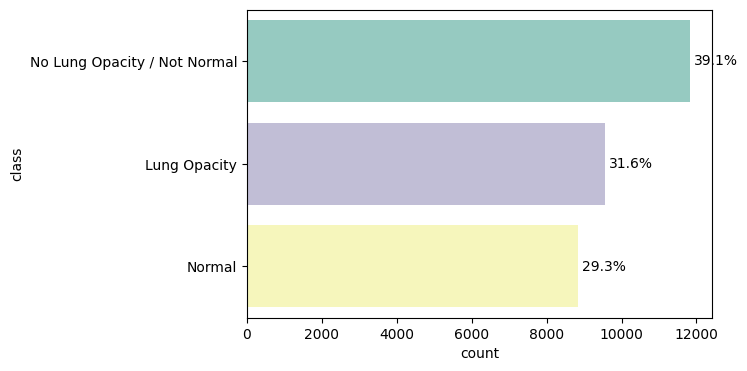

In [ ]:
f, ax = plt.subplots(1, 1, figsize=(6, 4))
total = float(len(class_info_df))
sns.countplot(
    data=class_info_df,
    y='class',
    order=class_info_df['class'].value_counts().index,
    palette='Set3',
    hue='class',
    legend=False
)

for p in ax.patches:
    value = p.get_width()
    percentage = '{:.1f}%'.format(100 * value / total)
    x = p.get_width() + 100
    y = p.get_y() + p.get_height() / 2

    ax.text(x, y, percentage, va='center')

plt.show()

In [ ]:
def get_feature_distribution(data, feature):
    # Get the count for each label
    label_counts = data[feature].value_counts()

    # Get total number of samples
    total_samples = len(data)

    # Count the number of items in each class
    print("Feature: {}".format(feature))
    for i in range(len(label_counts)):
        label = label_counts.index[i]
        count = label_counts.values[i]
        percent = int((count / total_samples) * 10000) / 100
        print("{:<30s}:   {} or {}%".format(label, count, percent))

get_feature_distribution(class_info_df, 'class')



Feature: class
No Lung Opacity / Not Normal  :   11821 or 39.1%
Lung Opacity                  :   9555 or 31.61%
Normal                        :   8851 or 29.28%


In [ ]:
train_class_df = train_labels_df.merge(class_info_df, left_on='patientId', right_on='patientId', how='inner')
train_class_df.sample(5)

,patientId,x,y,width,height,Target,class
19941,9bcff9c8-1eac-4ce1-a580-22362b3c9596,NaN,NaN,NaN,NaN,0,Normal
20252,9e4f11c9-edcf-48bb-adce-0b06d7ddda3d,NaN,NaN,NaN,NaN,0,Normal
7619,477cd50b-52f1-4994-871b-91cf32fa3174,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal
21485,a654732b-c9e4-471b-8109-6c51c10d6c27,NaN,NaN,NaN,NaN,0,Normal
33378,eee71ceb-52d2-4d63-acaf-5eab6f8d8932,NaN,NaN,NaN,NaN,0,No Lung Opacity / Not Normal


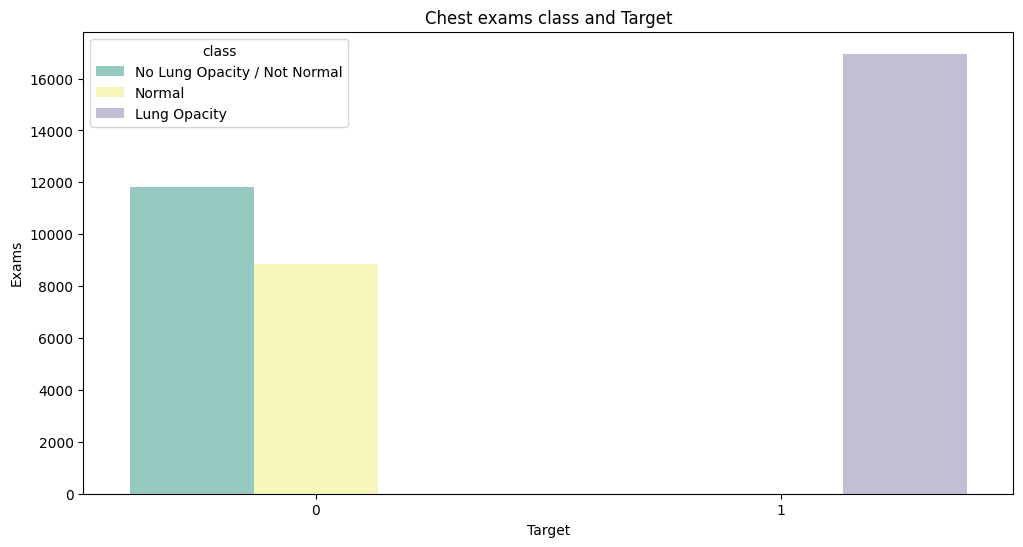

In [ ]:
fig, ax = plt.subplots(nrows=1,figsize=(12,6))
tmp = train_class_df.groupby('Target')['class'].value_counts()
df = pd.DataFrame(data={'Exams': tmp.values}, index=tmp.index).reset_index()
sns.barplot(ax=ax,x = 'Target', y='Exams',hue='class',data=df, palette='Set3')
plt.title("Chest exams class and Target")
plt.show()

/tmp/ipython-input-3955256213.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(target1['x'],kde=True,bins=50, color="red", ax=ax[0,0])
/tmp/ipython-input-3955256213.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(target1['y'],kde=True,bins=50, color="blue", ax=ax[0,1])
/tmp/ipython-input-

<Figure size 640x480 with 0 Axes>

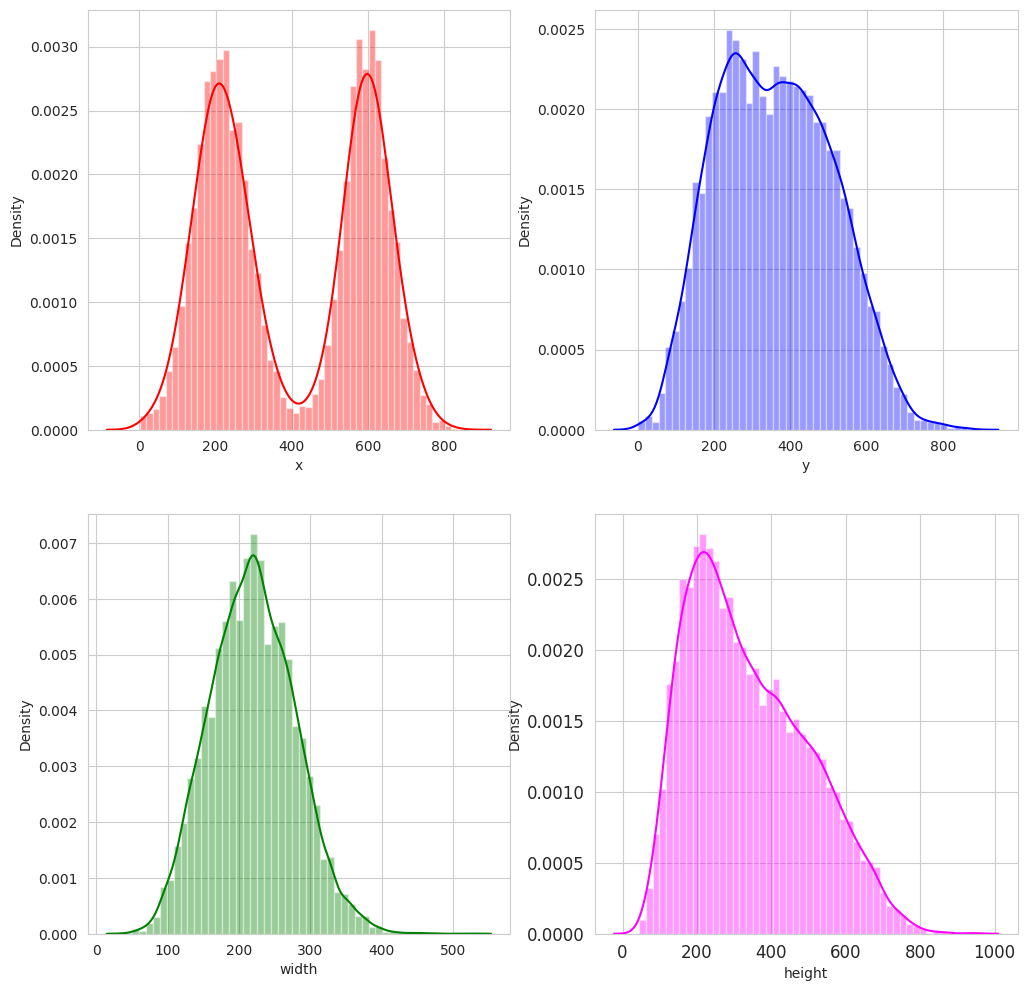

In [ ]:
target1 = train_class_df[train_class_df['Target']==1]
sns.set_style('whitegrid')
plt.figure()
fig, ax = plt.subplots(2,2,figsize=(12,12))
sns.distplot(target1['x'],kde=True,bins=50, color="red", ax=ax[0,0])
sns.distplot(target1['y'],kde=True,bins=50, color="blue", ax=ax[0,1])
sns.distplot(target1['width'],kde=True,bins=50, color="green", ax=ax[1,0])
sns.distplot(target1['height'],kde=True,bins=50, color="magenta", ax=ax[1,1])
locs, labels = plt.xticks()
plt.tick_params(axis='both', which='major', labelsize=12)
plt.show()

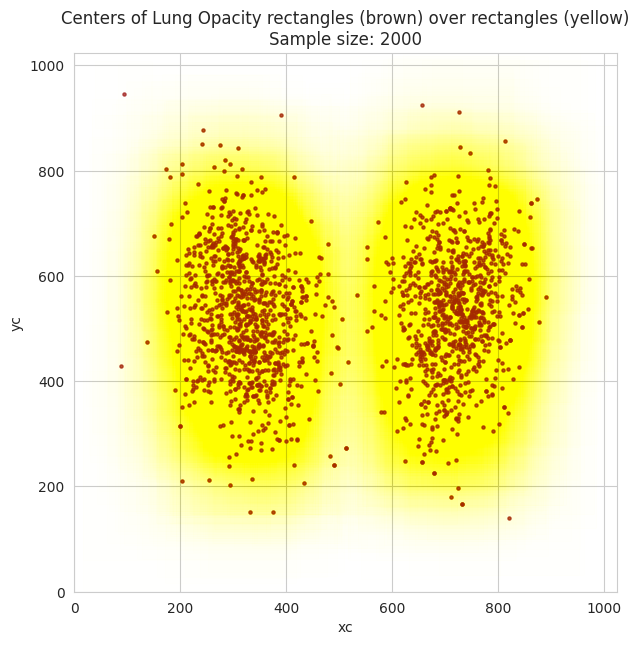

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(7,7))
target_sample = target1.sample(2000)
target_sample['xc'] = target_sample['x'] + target_sample['width'] / 2
target_sample['yc'] = target_sample['y'] + target_sample['height'] / 2
plt.title("Centers of Lung Opacity rectangles (brown) over rectangles (yellow)\nSample size: 2000")
target_sample.plot.scatter(x='xc', y='yc', xlim=(0,1024), ylim=(0,1024), ax=ax, alpha=0.8, marker=".", color="brown")
for i, crt_sample in target_sample.iterrows():
    ax.add_patch(Rectangle(xy=(crt_sample['x'], crt_sample['y']),
                width=crt_sample['width'],height=crt_sample['height'],alpha=3.5e-3, color="yellow"))
plt.show()

In [ ]:
image_train_path = os.listdir(PATH+'/stage_2_train_images')
image_test_path = os.listdir(PATH+'/stage_2_test_images')
print("Number of images in train set:", len(image_train_path),"\nNumber of images in test set:", len(image_test_path))

Number of images in train set: 26684 
Number of images in test set: 3000


In [ ]:
print("Unique patientId in  train_class_df: ", train_class_df['patientId'].nunique())

Unique patientId in  train_class_df:  26684


In [ ]:
tmp = train_class_df.groupby(['patientId','Target', 'class'])['patientId'].count()
df = pd.DataFrame(data={'Exams': tmp.values}, index=tmp.index).reset_index()
tmp = df.groupby(['Exams','Target','class']).count()
df2 = pd.DataFrame(data=tmp.values, index=tmp.index).reset_index()
df2.columns = ['Exams', 'Target','Class', 'Entries']
df2

,Exams,Target,Class,Entries
0,1,0,No Lung Opacity / Not Normal,11821
1,1,0,Normal,8851
2,1,1,Lung Opacity,2614
3,4,1,Lung Opacity,3266
4,9,1,Lung Opacity,119
5,16,1,Lung Opacity,13


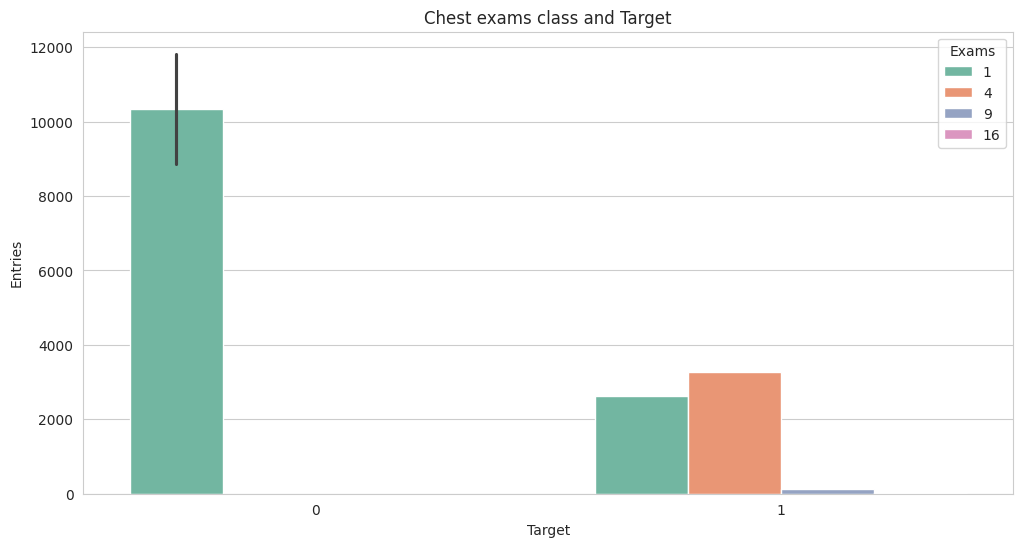

In [ ]:
fig, ax = plt.subplots(nrows=1,figsize=(12,6))
sns.barplot(ax=ax,x = 'Target', y='Entries', hue='Exams',data=df2, palette='Set2')
plt.title("Chest exams class and Target")
plt.show()

In [ ]:
def show_dicom_images(data):
    img_data = list(data.T.to_dict().values())
    f, ax = plt.subplots(3,3, figsize=(16,18))
    for i,data_row in enumerate(img_data):
        patientImage = data_row['patientId']+'.dcm'
        imagePath = os.path.join(PATH,"stage_2_train_images/",patientImage)
        data_row_img_data = dcm.dcmread(imagePath)
        modality = data_row_img_data.Modality
        age = data_row_img_data.PatientAge
        sex = data_row_img_data.PatientSex
        data_row_img = dcm.dcmread(imagePath)
        ax[i//3, i%3].imshow(data_row_img.pixel_array, cmap=plt.cm.bone)
        ax[i//3, i%3].axis('off')
        ax[i//3, i%3].set_title('ID: {}\nModality: {} Age: {} Sex: {} Target: {}\nClass: {}\nWindow: {}:{}:{}:{}'.format(
                data_row['patientId'],
                modality, age, sex, data_row['Target'], data_row['class'],
                data_row['x'],data_row['y'],data_row['width'],data_row['height']))
    plt.show()

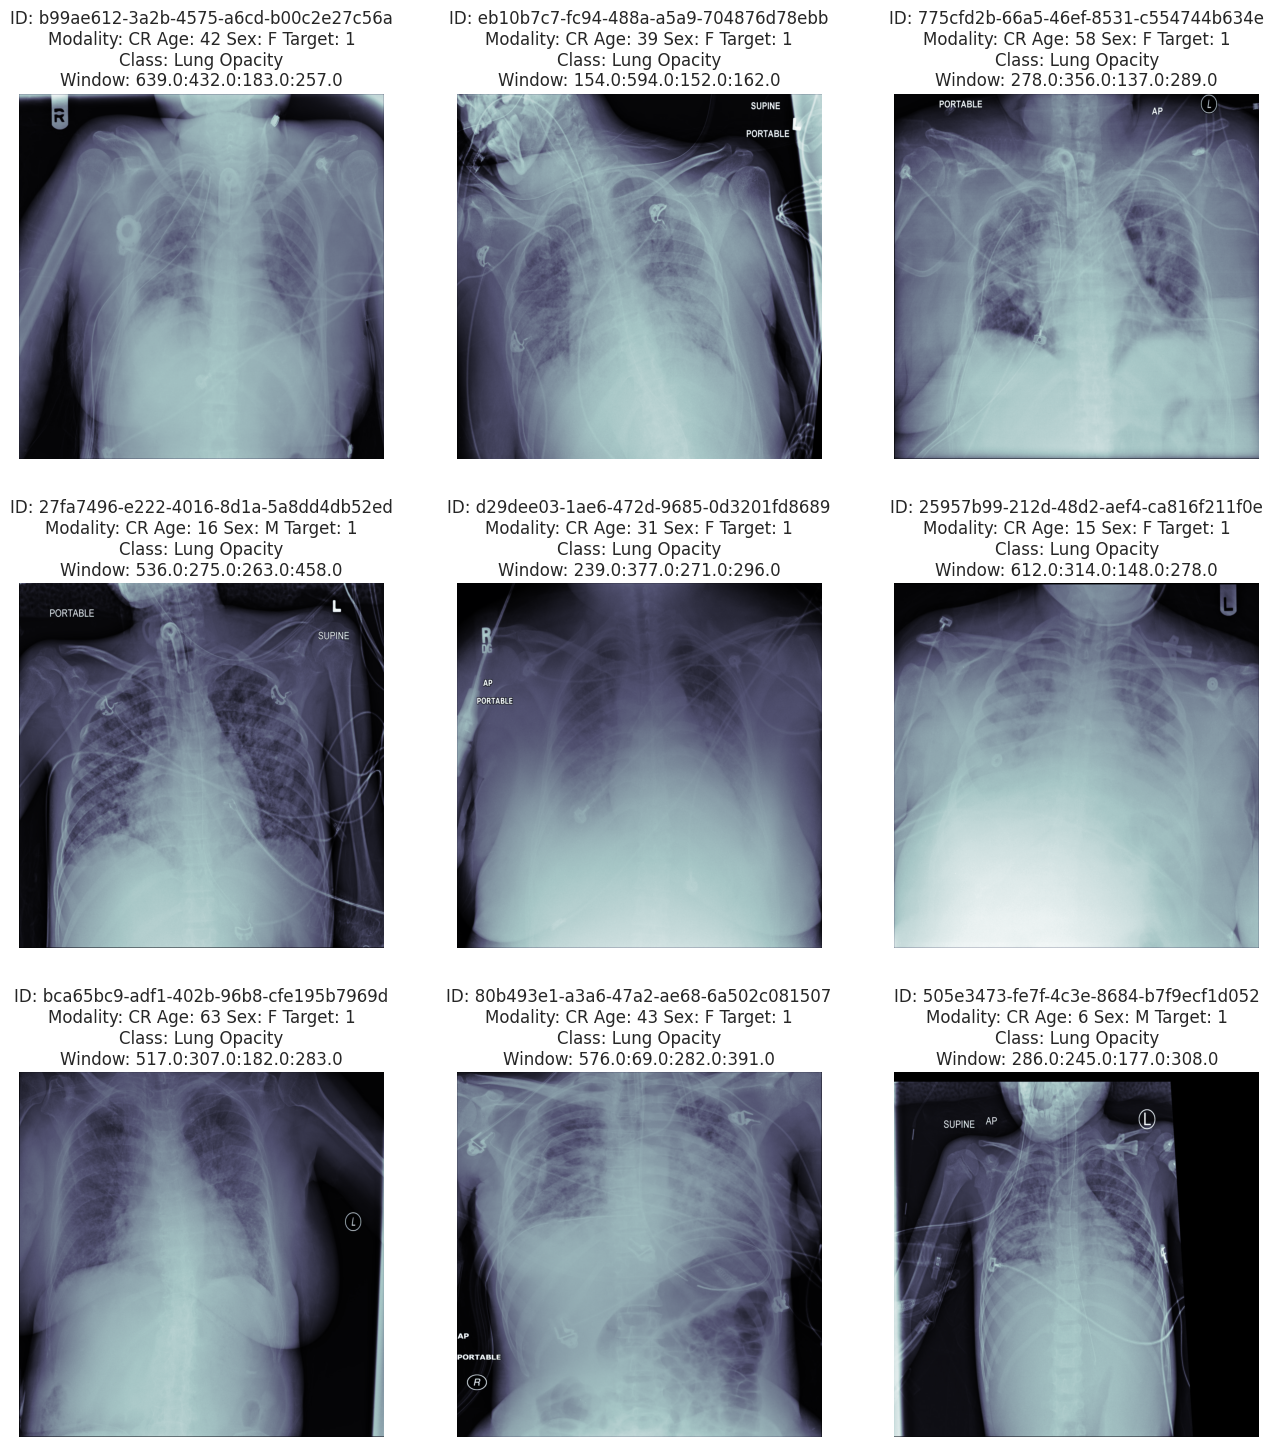

In [ ]:
show_dicom_images(train_class_df[train_class_df['Target']==1].sample(9))

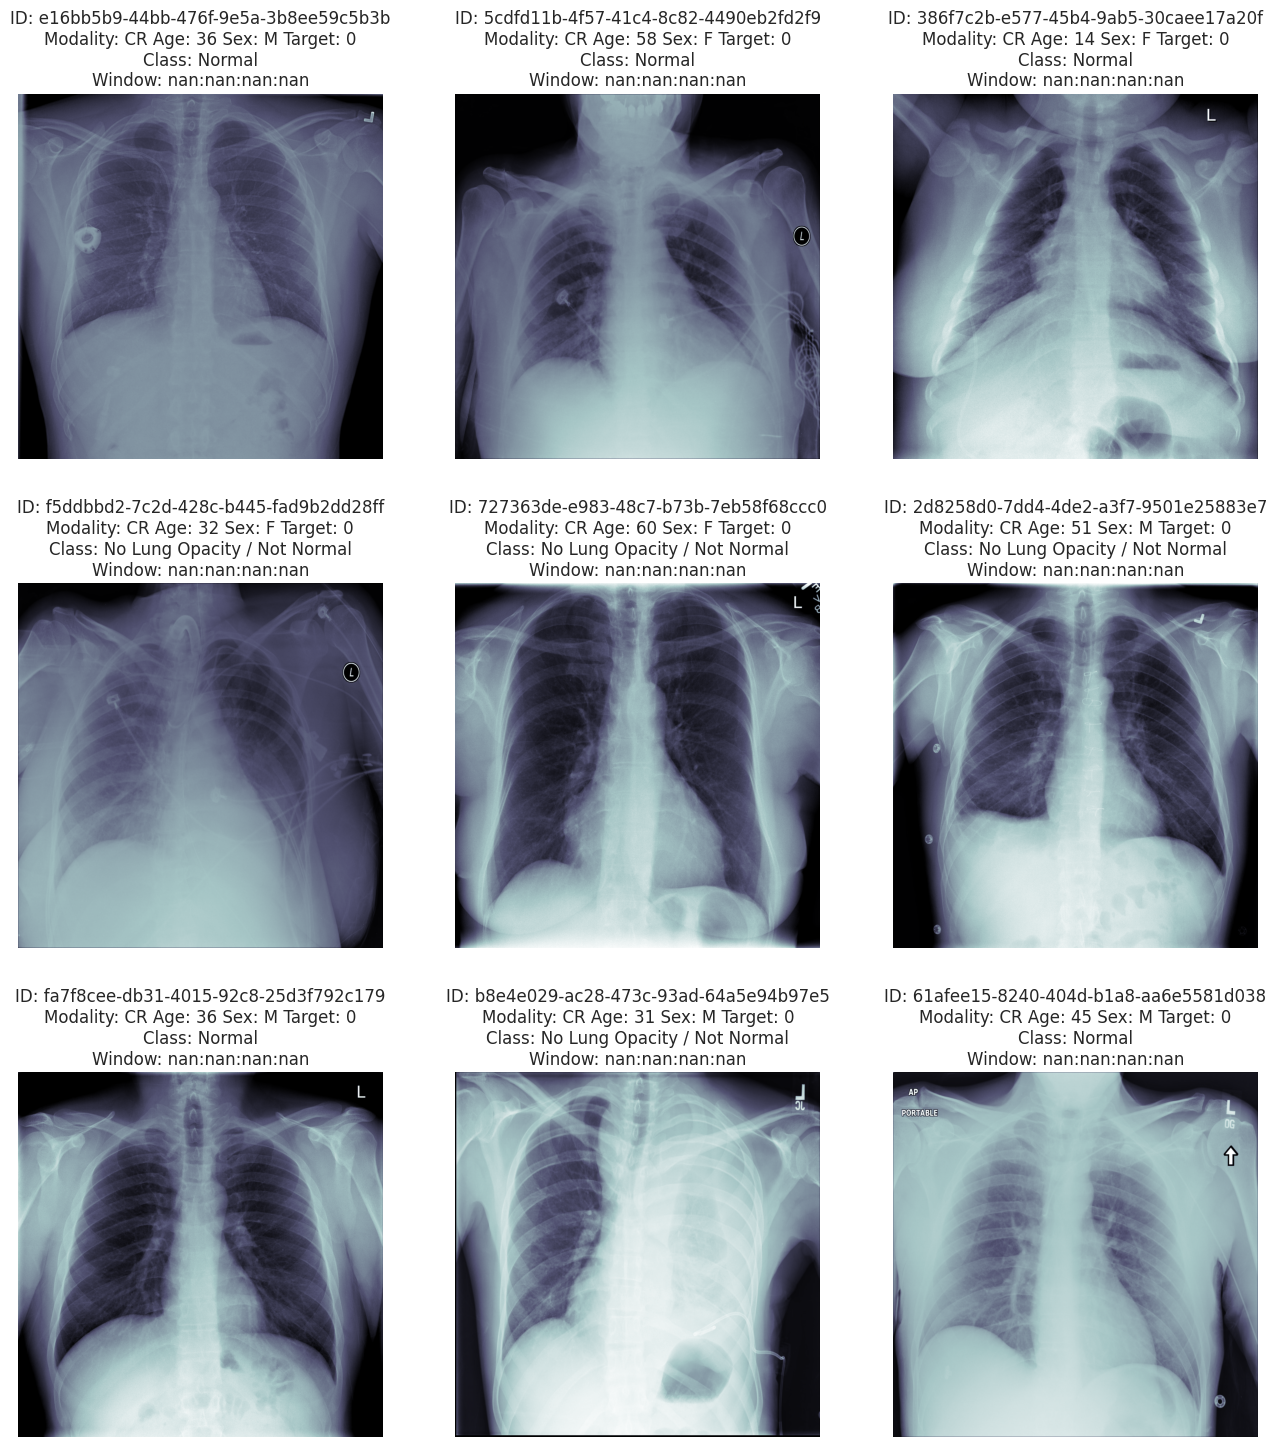

In [ ]:
show_dicom_images(train_class_df[train_class_df['Target']==0].sample(9))

In [ ]:
vars = ['Modality', 'PatientAge', 'PatientSex', 'BodyPartExamined', 'ViewPosition', 'ConversionType', 'Rows', 'Columns', 'PixelSpacing']

def process_dicom_data(data_df, data_path):
    for var in vars:
        data_df[var] = None
    image_names = os.listdir(PATH+data_path)
    for i, img_name in tqdm_notebook(enumerate(image_names)):
        imagePath = os.path.join(PATH,data_path,img_name)
        data_row_img_data = dcm.dcmread(imagePath)
        idx = (data_df['patientId']==data_row_img_data.PatientID)
        data_df.loc[idx,'Modality'] = data_row_img_data.Modality
        data_df.loc[idx,'PatientAge'] = pd.to_numeric(data_row_img_data.PatientAge)
        data_df.loc[idx,'PatientSex'] = data_row_img_data.PatientSex
        data_df.loc[idx,'BodyPartExamined'] = data_row_img_data.BodyPartExamined
        data_df.loc[idx,'ViewPosition'] = data_row_img_data.ViewPosition
        data_df.loc[idx,'ConversionType'] = data_row_img_data.ConversionType
        data_df.loc[idx,'Rows'] = data_row_img_data.Rows
        data_df.loc[idx,'Columns'] = data_row_img_data.Columns
        data_df.loc[idx,'PixelSpacing'] = str.format("{:4.3f}",data_row_img_data.PixelSpacing[0])

In [ ]:
process_dicom_data(train_class_df,'stage_2_train_images/')

/tmp/ipython-input-2787178028.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i, img_name in tqdm_notebook(enumerate(image_names)):


0it [00:00, ?it/s]

In [ ]:
test_class_df = pd.read_csv(PATH+'/stage_2_sample_submission.csv')

In [ ]:
test_class_df = test_class_df.drop('PredictionString',axis=1)
process_dicom_data(test_class_df,'stage_2_test_images/')

/tmp/ipython-input-2787178028.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i, img_name in tqdm_notebook(enumerate(image_names)):


0it [00:00, ?it/s]

In [ ]:
print("Modalities: train:",train_class_df['Modality'].unique(), "test:", test_class_df['Modality'].unique())

Modalities: train: ['CR'] test: ['CR']


In [ ]:
print("Body Part Examined: train:",train_class_df['BodyPartExamined'].unique(), "test:", test_class_df['BodyPartExamined'].unique())

Body Part Examined: train: ['CHEST'] test: ['CHEST']


In [ ]:
get_feature_distribution(train_class_df,'ViewPosition')

Feature: ViewPosition
AP                            :   21817 or 57.97%
PA                            :   15812 or 42.02%


##DATASET CREATION


In [ ]:
# 1. Clean and Group Data
def get_grouped_dataframe(csv_path):
    df = pd.read_csv(csv_path)
    df.fillna(0, inplace=True)
    grouped = df.groupby('patientId').agg({
        'x': list,
        'y': list,
        'width': list,
        'height': list,
        'Target': list
    }).reset_index()
    return grouped

In [ ]:
class RSNADataset(Dataset):
    def __init__(self, dataframe, image_dir, transforms=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        #retrieve data
        row = self.df.iloc[idx]
        dcm_data = dcm.dcmread(f"{self.image_dir}/{row['patientId']}.dcm")
        img = dcm_data.pixel_array
        img = Image.fromarray(img).convert("RGB")

        # --- NEW: Resize Logic ---
        original_size = 1024
        target_size = 512
        scale = target_size / original_size # 0.5

        # Resize Image
        img = img.resize((target_size, target_size), resample=Image.BILINEAR)
        # -------------------------

        boxes = []
        labels = []

        if row['Target'][0] == 1:
            for i in range(len(row['x'])):
                # Scale the coordinates
                x = row['x'][i] * scale
                y = row['y'][i] * scale
                w = row['width'][i] * scale
                h = row['height'][i]

                boxes.append([x, y, x + w, y + h])
                labels.append(1)
        else:
             boxes = torch.zeros((0, 4), dtype=torch.float32)
             labels = torch.zeros((0), dtype=torch.int64)

        #to tensors
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = torch.tensor([idx])

        # 5. Apply Transforms (Augmentations)
        if self.transforms:
            # Note: You need a transform library that handles bounding boxes
            # like Albumentations, or write custom logic.
            # For now, we assume simple ToTensor() on the image only.
            img = self.transforms(img)

        return img, target

In [ ]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [ ]:
# Setup
labels_df = get_grouped_dataframe('stage_2_train_labels.csv')
img_dir = 'stage_2_train_images'

#basic transforms
def get_transform():
    transforms = []
    transforms.append(T.ToTensor()) # Converts 0-255 PIL to 0-1 Tensor
    return T.Compose(transforms)

# Dataset
dataset = RSNADataset(labels_df, img_dir, transforms=get_transform())

# Loader (Pass the collate_fn here!)
data_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

# Test one batch
images, targets = next(iter(data_loader))
print(f"Batch loaded. Image shape: {images[0].shape}")
print(f"First image boxes: {targets[0]['boxes']}")

Batch loaded. Image shape: torch.Size([3, 512, 512])
First image boxes: tensor([], size=(0, 4))


In [ ]:
# Loop until we find a target with boxes
for images, targets in data_loader:
    # Check if the first image in batch has boxes
    if targets[0]['boxes'].shape[0] > 0:
        print(f"Found Positive Sample!")
        print(f"Image Shape: {images[0].shape}")
        print(f"Boxes (xyxy): \n{targets[0]['boxes']}")
        print(f"Labels: {targets[0]['labels']}")
        break

Found Positive Sample!
Image Shape: torch.Size([3, 512, 512])
Boxes (xyxy): 
tensor([[151.0000, 202.0000, 246.0000, 556.0000],
        [267.0000, 180.0000, 394.5000, 576.0000]])
Labels: tensor([1, 1])


In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cuda


In [ ]:
def save_checkpoint(model, optimizer, epoch, loss, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)

In [ ]:
def get_model(num_classes):
    #retinanet
    model = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")

    # Replace head for 2 classes (Background + Pneumonia)
    # in_features = model.head.classification_head.conv[0].in_channels
    in_features = 256
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = torchvision.models.detection.retinanet.RetinaNetClassificationHead(
        in_features, num_anchors, num_classes
    )
    return model

#Hyperparameters
num_classes = 2 # 0=Background, 1=Pneumonia
num_epochs = 2
lr = 0.005      # RetinaNet likes lower LRs usually
momentum = 0.9
weight_decay = 0.0005

#init
model = get_model(num_classes)
model.to(device)

#sgd for optimizer (adam could be unstable here)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)

#learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
#scaler for speedup
scaler = GradScaler()

best_loss = float('inf')
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True)


print(f"Starting training")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train() # CRITICAL: Switches model to return losses, not predictions

    epoch_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        #move to gpu
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        #forward pass
        # loss_dict = model(images, targets)

        #sum the losses
        # losses = sum(loss for loss in loss_dict.values())

        #backward pass
        optimizer.zero_grad()
        with autocast():
          loss_dict = model(images, targets)
          losses = sum(loss for loss in loss_dict.values())
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        #gradient clipping to prevent exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        optimizer.step()

        epoch_loss += losses.item()

        if i % 100 == 0:
            print(f"Epoch: {epoch+1}, Step: {i}, Loss: {losses.item():.4f}")

    #scheduler update
    lr_scheduler.step()
    avg_loss = epoch_loss/len(data_loader)
    save_path_last = os.path.join(save_dir, 'checkpoint_last.pth')
    save_checkpoint(model, optimizer, epoch, avg_loss, save_path_last)


    print(f"Epoch {epoch+1} Finished. Avg Loss: {epoch_loss/len(data_loader):.4f}. Time: {time.time()-start_time:.0f}s")

    if avg_loss < best_loss:
        print(f"Loss improved from {best_loss:.4f} to {avg_loss:.4f}. Saving best model...")
        best_loss = avg_loss
        save_path_best = os.path.join(save_dir, 'best_model.pth')
        torch.save(model.state_dict(), save_path_best) # For inference, we only need weights

    print(f"Epoch {epoch+1} Saved.")

# Save the model
torch.save(model.state_dict(), 'rsna_retinanet.pth')
print("Model saved!")

Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 184MB/s]
/tmp/ipython-input-1256012744.py:32: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Starting training


/tmp/ipython-input-1256012744.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch: 1, Step: 0, Loss: 0.3985
Epoch: 1, Step: 100, Loss: 0.3058
Epoch: 1, Step: 200, Loss: 0.2918
Epoch: 1, Step: 300, Loss: 0.3532
Epoch: 1, Step: 400, Loss: 0.5108
Epoch: 1, Step: 500, Loss: 0.1984
Epoch: 1, Step: 600, Loss: 0.0895
Epoch: 1, Step: 700, Loss: 0.4794
Epoch: 1, Step: 800, Loss: 0.2955
Epoch: 1, Step: 900, Loss: 0.4015
Epoch: 1, Step: 1000, Loss: 0.1214
Epoch: 1, Step: 1100, Loss: 0.3197
Epoch: 1, Step: 1200, Loss: 0.3150
Epoch: 1, Step: 1300, Loss: 0.3549
Epoch: 1, Step: 1400, Loss: 0.1194
Epoch: 1, Step: 1500, Loss: 0.2688
Epoch: 1, Step: 1600, Loss: 0.0727
Epoch 1 Finished. Avg Loss: 0.2960. Time: 2683s
Loss improved from inf to 0.2960. Saving best model...
Epoch 1 Saved.
Epoch: 2, Step: 0, Loss: 0.1669
Epoch: 2, Step: 100, Loss: 0.2307
Epoch: 2, Step: 200, Loss: 0.3421
Epoch: 2, Step: 300, Loss: 0.1181
Epoch: 2, Step: 400, Loss: 0.1927
Epoch: 2, Step: 500, Loss: 0.3592
Epoch: 2, Step: 600, Loss: 0.1955
Epoch: 2, Step: 700, Loss: 0.3249
Epoch: 2, Step: 800, Loss: 0.

In [ ]:
# --- CONFIGURATION ---
resume_training = True  # <--- SET THIS TO TRUE TO LOAD MODEL
checkpoint_path = 'rsna_retinanet.pth' # Path to your saved file
fine_tune_lr = 0.005   # Lower LR for fine-tuning (10x smaller)
start_lr = 0.005        # Standard LR for fresh training

# Hyperparameters
num_classes = 2
num_epochs = 3          # Add more epochs since you are resuming
momentum = 0.9
weight_decay = 0.0005
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# --- MODEL SETUP ---
def get_model(num_classes):
    model = torchvision.models.detection.retinanet_resnet50_fpn(weights="DEFAULT")
    in_features = 256
    num_anchors = model.head.classification_head.num_anchors
    model.head.classification_head = torchvision.models.detection.retinanet.RetinaNetClassificationHead(
        in_features, num_anchors, num_classes
    )
    return model

# Initialize Model
model = get_model(num_classes)
model.to(device)

# --- RESUME LOGIC ---
if resume_training and os.path.exists(checkpoint_path):
    print(f"Loading weights from {checkpoint_path}...")
    # Load weights
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    current_lr = fine_tune_lr
    print(f"Resuming with Fine-Tuning Learning Rate: {current_lr}")
else:
    print("Starting Fresh Training...")
    current_lr = start_lr

# --- OPTIMIZER & SCALER ---
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.SGD(params, lr=current_lr, momentum=momentum, weight_decay=weight_decay)

# Scheduler (Optional: resets step if fine-tuning, but that's okay)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)
scaler = GradScaler()

# Checkpoint Setup
best_loss = float('inf')
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True)

# Helper function (ensure this is defined)
def save_checkpoint(model, optimizer, epoch, loss, filename):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)

# --- TRAINING LOOP ---
print(f"Starting training loop...")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    epoch_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        # Move to GPU
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Zero Grads
        optimizer.zero_grad()

        # Forward Pass (Mixed Precision)
        with autocast():
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Backward Pass
        scaler.scale(losses).backward()

        # Unscale before clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        # Step
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += losses.item()

        if i % 100 == 0:
            print(f"Epoch: {epoch+1}, Step: {i}, Loss: {losses.item():.4f}")

    # Scheduler Step
    lr_scheduler.step()

    # Calculate Average Loss
    avg_loss = epoch_loss / len(data_loader)
    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1} Finished. Avg Loss: {avg_loss:.4f}. Time: {elapsed:.0f}s")

    # Save Last Checkpoint
    save_path_last = os.path.join(save_dir, 'checkpoint_last.pth')
    save_checkpoint(model, optimizer, epoch, avg_loss, save_path_last)

    # Save Best Model
    if avg_loss < best_loss:
        print(f"Loss improved from {best_loss:.4f} to {avg_loss:.4f}. Saving best model...")
        best_loss = avg_loss
        save_path_best = os.path.join(save_dir, 'best_model.pth')
        torch.save(model.state_dict(), save_path_best)

    print(f"Epoch {epoch+1} Saved.")

# Save Final
torch.save(model.state_dict(), 'rsna_retinanet_finetuned.pth')
print("Training Complete. Final model saved.")

##Model testing

In [ ]:
# 1. Load the Model Architecture & Weights
# (Ensure get_model is defined as discussed previously)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model = get_model(num_classes=2)
model.load_state_dict(torch.load('rsna_retinanet.pth'))
model.to(device)

# CRITICAL: Switch to Eval mode.
# If you forget this, the model will error out expecting targets!
model.eval()

def make_prediction(image_path, threshold=0.5):
    # 2. Preprocess Image
    dcm_data = dcm.dcmread(image_path)
    img = dcm_data.pixel_array

    # Convert to RGB (1 channel -> 3 channels)
    img_pil = Image.fromarray(img).convert("RGB")

    # Convert to Tensor (0-1 range)
    transform = T.Compose([T.ToTensor()])
    img_tensor = transform(img_pil).to(device)

    # 3. Forward Pass
    # We must add a batch dimension: [C, H, W] -> [1, C, H, W]
    with torch.no_grad():
        prediction = model([img_tensor]) # List of images

    # 4. Filter Results
    # The model returns a list of dictionaries (one per image)
    pred_boxes = prediction[0]['boxes'].cpu().numpy()
    pred_scores = prediction[0]['scores'].cpu().numpy()

    # Keep only predictions with high confidence
    mask = pred_scores > threshold
    filtered_boxes = pred_boxes[mask]
    filtered_scores = pred_scores[mask]

    return img, filtered_boxes, filtered_scores

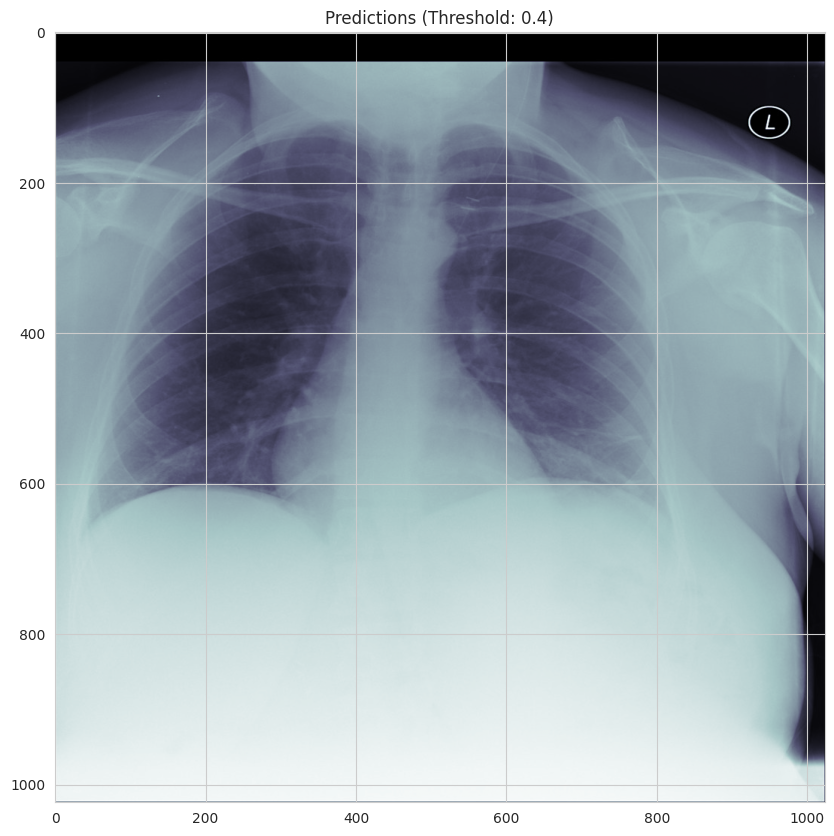

In [ ]:
def show_prediction(image_path):
    # Get predictions
    img_array, boxes, scores = make_prediction(image_path, threshold=0.4)

    # Plot
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(img_array, cmap='bone')

    for i, box in enumerate(boxes):
        # Decode box (x_min, y_min, x_max, y_max)
        xmin, ymin, xmax, ymax = box
        width = xmax - xmin
        height = ymax - ymin

        # Draw Rectangle
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2, edgecolor='r', facecolor='none'
        )
        ax.add_patch(rect)

        # Add Score Label
        ax.text(xmin, ymin - 10, f"{scores[i]:.2f}", color='red', fontsize=12, weight='bold')

    plt.title(f"Predictions (Threshold: 0.4)")
    plt.show()

# Run on a random test image

test_dir = 'stage_2_test_images'
random_file = random.choice(os.listdir(test_dir))
show_prediction(os.path.join(test_dir, random_file))

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.8 MB/s eta 0:00:00


In [ ]:
# 1. Filter for Pneumonia cases (Target is a list, so we check the first item)
positive_cases = labels_df[labels_df['Target'].apply(lambda x: x[0] == 1)]

# Debug: Print how many we found to be sure
print(f"Found {len(positive_cases)} positive cases.")

# 2. Pick a random patient ID
random_row = positive_cases.sample(1).iloc[0]
patient_id = random_row['patientId']

# 3. Construct Path and Show
img_path = os.path.join('stage_2_train_images', f"{patient_id}.dcm")
print(f"Checking Patient: {patient_id}")

# show_prediction(img_path)
make_prediction(img_path)

Found 6012 positive cases.
Checking Patient: b0502b9f-b85c-4cac-9e8f-325ed59315e0


(array([[ 0,  0,  1, ...,  0,  0,  0],
        [ 3,  5,  6, ...,  4,  4,  3],
        [ 4,  6,  7, ...,  5,  4,  4],
        ...,
        [12, 25, 26, ..., 27, 34, 16],
        [13, 26, 26, ..., 27, 33, 19],
        [ 4, 16, 14, ..., 12, 19,  8]], dtype=uint8),
 array([], shape=(0, 4), dtype=float32),
 array([], dtype=float32))

Searching through 6012 positive patients for a match...
Found a match! Patient: 729c9ee1-d716-4b76-b5e7-690d6e914ea8 | Max Score: 0.41


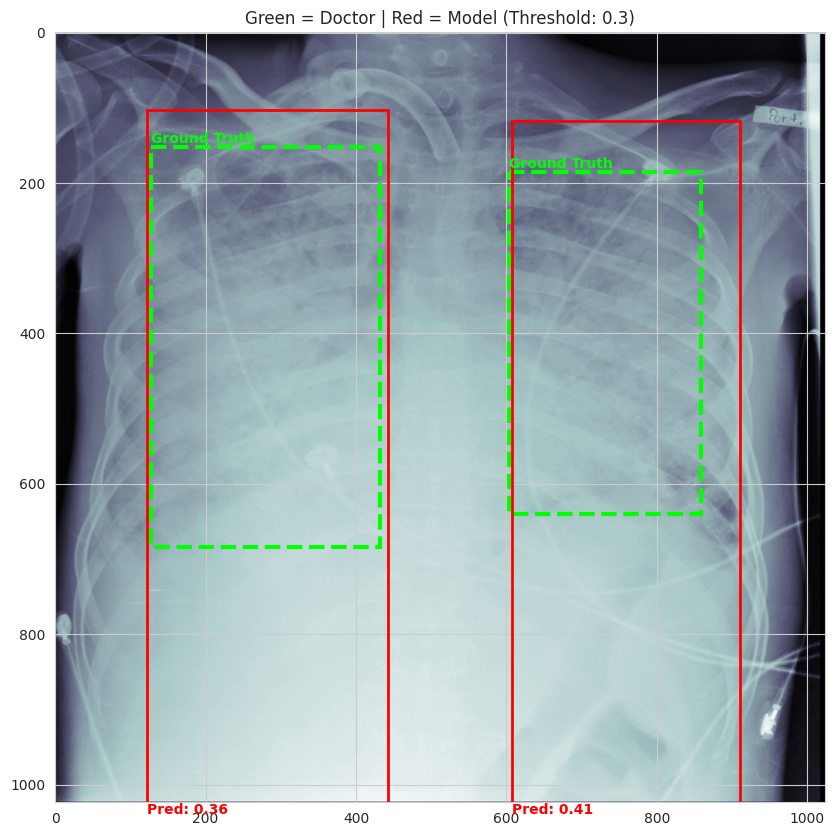

In [ ]:
def find_successful_prediction(threshold=0.3):
    # 1. Get all pneumonia patients
    positive_cases = labels_df[labels_df['Target'].apply(lambda x: x[0] == 1)]
    patient_ids = positive_cases['patientId'].unique()

    print(f"Searching through {len(patient_ids)} positive patients for a match...")

    # 2. Check random patients until we find a match
    for _ in range(50): # Try up to 50 times
        pid = random.choice(patient_ids)
        path = os.path.join('stage_2_train_images', f"{pid}.dcm")

        # Predict
        _, _, scores = make_prediction(path, threshold=threshold)

        # If we found a box with high confidence, show it!
        if len(scores) > 0 and max(scores) > threshold:
            print(f"Found a match! Patient: {pid} | Max Score: {max(scores):.2f}")
            show_comparison(pid, threshold=threshold) # Re-use your comparison function
            return

    print("No high-confidence matches found in this batch. Try lowering the threshold.")

# Run the hunter
find_successful_prediction(threshold=0.3)

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.model_selection import train_test_split

# 1. Setup Validation Loader
# We split the dataframe indices to create a proper validation set
train_idx, val_idx = train_test_split(range(len(labels_df)), test_size=0.2, random_state=42)

# Create the subset and loader
val_dataset = Subset(dataset, val_idx)
val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

# 2. Initialize Metric
# 'class_metrics=True' lets you see score for Pneumonia specifically
metric = MeanAveragePrecision(class_metrics=True)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 3. Evaluation Loop
print("Evaluating model on validation set...")
model.eval()

with torch.no_grad():
    for i,(images, targets) in enumerate(val_loader):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        preds = model(images)

        # Update Metric
        metric.update(preds, targets)
        if i % 100 == 0:
          print(metric)

# 4. Compute & Print
results = metric.compute()

print("\n--- Validation Results ---")
print(f"mAP (IoU=0.50:0.95): {results['map']:.4f}")
print(f"mAP (IoU=0.50):      {results['map_50']:.4f}") # <--- Important for Kaggle
print(f"mAP (IoU=0.75):      {results['map_75']:.4f}")

Evaluating model on validation set...
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()
MeanAveragePrecision()

--- Validation Results ---
mAP (IoU=0.50:0.95): 0.0849
mAP (IoU=0.50):      0.3477
mAP (IoU=0.75):      0.0115


In [ ]:
# Settings
test_dir = 'stage_2_test_images'
submission_path = 'submission.csv'
min_confidence = 0.3 # Tune this! 0.3 is a safe starting point.

# 1. Setup Model (Ensure it's loaded and in eval mode)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.eval()

results = []
test_files = os.listdir(test_dir)

print(f"Generating predictions for {len(test_files)} images...")

with torch.no_grad():
    for fname in tqdm(test_files):
        # A. Prepare Image
        path = os.path.join(test_dir, fname)

        # Load and Preprocess (Exactly like Validation)
        dcm_data = dcm.dcmread(path)
        img_arr = dcm_data.pixel_array
        img_pil = Image.fromarray(img_arr).convert("RGB")

        # Resize to 512 for the model
        img_input = img_pil.resize((512, 512), resample=Image.BILINEAR)
        img_tensor = T.ToTensor()(img_input).to(device)

        # B. Predict
        # Input: [1, C, H, W]
        prediction = model([img_tensor])[0]

        # C. Format Prediction String
        prediction_string = []

        boxes = prediction['boxes'].cpu().numpy()
        scores = prediction['scores'].cpu().numpy()

        for i, score in enumerate(scores):
            if score > min_confidence:
                # Get Box Coordinates (in 512x512 space)
                xmin, ymin, xmax, ymax = boxes[i]

                # --- CRITICAL: RESCALE TO 1024x1024 ---
                # Multiply by 2 because 1024/512 = 2
                scale_factor = 1024 / 512
                xmin *= scale_factor
                ymin *= scale_factor
                xmax *= scale_factor
                ymax *= scale_factor

                # Convert xyxy -> xywh (Kaggle requires x, y, width, height)
                width = xmax - xmin
                height = ymax - ymin

                # Format: "score x y w h"
                prediction_string.append(f"{score:.4f} {xmin:.1f} {ymin:.1f} {width:.1f} {height:.1f}")

        # Join multiple boxes with a space, or leave empty if none found
        result_str = " ".join(prediction_string)

        # Save (Remove .dcm extension for patientId)
        results.append({"patientId": fname.replace('.dcm', ''), "PredictionString": result_str})

# 2. Save to CSV
submission_df = pd.DataFrame(results)
submission_df.to_csv(submission_path, index=False)

print(f"Done! Saved to {submission_path}")
print(submission_df.head())

Generating predictions for 3000 images...


100%|██████████| 3000/3000 [04:57<00:00, 10.10it/s]


Done! Saved to submission.csv
                              patientId PredictionString
0  1db1d9fe-551a-4aaa-abd2-a8353eb82ced                 
1  233e0be9-7a88-48f7-b5e3-af50cb2ccb4b                 
2  0f7b0aff-0bb2-462d-beb3-e8c98c30b654                 
3  27bfde5e-6542-424d-b772-f92e99e22faa                 
4  1f8ab482-338a-4b66-837e-a6c510e18607                 
